In [1]:
import pandas as pd

In [2]:
raw_new_construction_df = pd.read_csv("../raw_data/new_construction.csv")
raw_kiez_prices_monthly_df = pd.read_csv("../raw_data/kiez_prices_monthly.csv")
raw_transit_stations_df = pd.read_csv("../raw_data/transit_stations.csv")
raw_secondary_sales_df = pd.read_csv("../raw_data/secondary_sales.csv")
raw_rentals_df = pd.read_csv("../raw_data/rentals.csv")


In [3]:
pd.set_option('display.max_columns', None)
print(raw_new_construction_df.shape)
print(raw_kiez_prices_monthly_df.shape)
print(raw_transit_stations_df.shape)
print(raw_secondary_sales_df.shape)
print(raw_rentals_df.shape)


(10000, 31)
(6232, 13)
(135, 6)
(50000, 31)
(30000, 30)


In [4]:
raw_secondary_sales_df

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


## Linear regression: price_eur ~ area_m2

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = raw_secondary_sales_df[["area_m2"]]
y = raw_secondary_sales_df["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"intercept: {model.intercept_:.2f}")
print(f"coefficient (price_eur per m2): {model.coef_[0]:.2f}")
print(f"R2 on test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE on test set: {mean_absolute_error(y_test, y_pred):.2f}")


intercept: -53796.11
coefficient (price_eur per m2): 4793.33
R2 on test set: 0.5267
MAE on test set: 114177.53


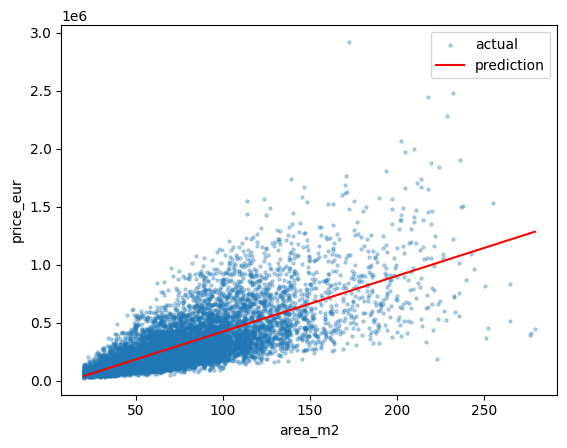

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, s=5, alpha=0.3, label="actual")
plt.plot(X_test.sort_values("area_m2"), model.predict(X_test.sort_values("area_m2")), color="red", label="prediction")
plt.xlabel("area_m2")
plt.ylabel("price_eur")
plt.legend()
plt.show()


In [ ]:
raw_new_construction_df = pd.read_csv("../raw_data/new_construction.csv")
raw_kiez_prices_monthly_df = pd.read_csv("../raw_data/kiez_prices_monthly.csv")
raw_transit_stations_df = pd.read_csv("../raw_data/transit_stations.csv")
raw_secondary_sales_df = pd.read_csv("../raw_data/secondary_sales.csv")
raw_rentals_df = pd.read_csv("../raw_data/rentals.csv")


In [3]:
pd.set_option('display.max_columns', None)
print(raw_new_construction_df.shape)
print(raw_kiez_prices_monthly_df.shape)
print(raw_transit_stations_df.shape)
print(raw_secondary_sales_df.shape)
print(raw_rentals_df.shape)


(10000, 31)
(6232, 13)
(135, 6)
(50000, 31)
(30000, 30)


In [4]:
raw_secondary_sales_df

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


## Linear regression: price_eur ~ area_m2

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = raw_secondary_sales_df[["area_m2"]]
y = raw_secondary_sales_df["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"intercept: {model.intercept_:.2f}")
print(f"coefficient (price_eur per m2): {model.coef_[0]:.2f}")
print(f"R2 on test set: {r2_score(y_test, y_pred):.4f}")
print(f"MAE on test set: {mean_absolute_error(y_test, y_pred):.2f}")


intercept: -53796.11
coefficient (price_eur per m2): 4793.33
R2 on test set: 0.5267
MAE on test set: 114177.53


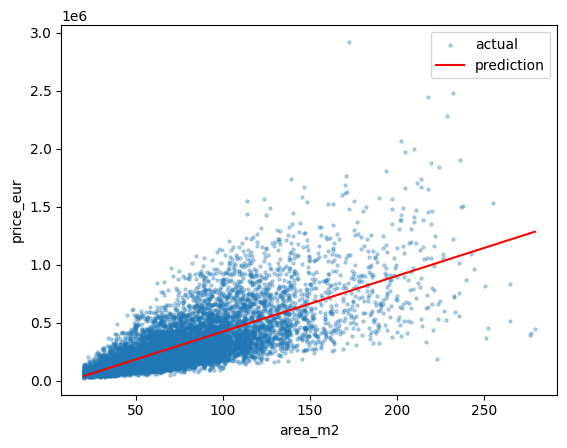

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, s=5, alpha=0.3, label="actual")
plt.plot(X_test.sort_values("area_m2"), model.predict(X_test.sort_values("area_m2")), color="red", label="prediction")
plt.xlabel("area_m2")
plt.ylabel("price_eur")
plt.legend()
plt.show()
